<a href="https://colab.research.google.com/github/NguyenDung0210/Attribute-Driven_Counterfactual_Brain_MRI_with_GANs/blob/dev/src/StyleGAN/style_ganv1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install lightning -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 85.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 56.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

[Weight](https://drive.google.com/file/d/1kMA9Dn-K7Vx88dRkp4qFvj6_CFuxY8FO/view?usp=sharing)



# Import and Configuration



In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision
import pytorch_lightning as pl
from torch.utils.data import DataLoader, Dataset
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor
from pytorch_lightning.loggers import TensorBoardLogger
import matplotlib.pyplot as plt
import pickle
from collections import defaultdict
import random
import nibabel as nib
import pandas as pd
from PIL import Image
from IPython.display import Image, display
import time
from skimage.transform import resize

# ==================== CONFIGURATION SECTION ====================
# Chỉnh sửa các thông số ở đây để dễ dàng thay đổi cấu hình

class Config:
    # Model Architecture
    LATENT_DIM = 512
    STYLE_DIM = 512
    NUM_MAPPING_LAYERS = 8
    NUM_STYLE_LAYERS = 14
    CONDITION_DIM = 2  # [age, gender]

    # Image Settings
    IMAGE_SIZE = 128
    NUM_CHANNELS = 3  # [Axial, Coronal, Sagittal]
    BASE_RESOLUTION = 4
    BASE_CHANNELS = 512
    MIN_CHANNELS = 16

    # Training Settings
    BATCH_SIZE = 32
    NUM_EPOCHS = 100
    LEARNING_RATE = 0.0001
    BETA1 = 0.0
    BETA2 = 0.99

    # Gradient Penalty
    START_LAMBDA_GP = 10.0
    DECAY_LAMBDA_GP = True
    MIN_LAMBDA_GP = 0.1
    LAMBDA_GP_DECAY_RATE = 0.99

    # Training Strategy
    DISCRIMINATOR_STEPS = 2  # Train D n times per G step
    STYLE_MIXING_PROB = 0.9

    # Data Settings
    TARGET_SHAPE = (128, 128)
    TRAIN_SPLIT = 0.9
    MIN_AGE = 10
    MAX_AGE = 90
    SAMPLE_MIN_AGE = 20  # For visualization
    SAMPLE_MAX_AGE = 80  # For visualization
    NORMALIZE_RANGE = (-1, 1)

    # Validation & Logging
    CHECK_VAL_EVERY_N_EPOCH = 1
    LOG_EVERY_N_STEPS = 10
    DISPLAY_EVERY_N_EPOCHS = 10
    NUM_VALIDATION_SAMPLES = 8

    # Paths
    CHECKPOINT_DIR = "/content/src/StyleGAN/checkpoints/"
    LOG_DIR = "/content/src/StyleGAN/logs/"
    RESULTS_DIR = "/content/src/StyleGAN/results/"

    # Hardware
    NUM_WORKERS = 4
    PIN_MEMORY = True

    # Visualization
    CHANNEL_NAMES = ['Axial', 'Coronal', 'Sagittal']
    VALIDATION_CONDITIONS = [
        [0.0, 0], [0.0, 1], [0.2, 0], [0.2, 1],
        [0.5, 0], [0.5, 1], [0.8, 0], [0.8, 1]
    ]

# ==================== END CONFIGURATION SECTION ====================

os.makedirs(Config.RESULTS_DIR, exist_ok=True)
os.makedirs(Config.CHECKPOINT_DIR, exist_ok=True)
os.makedirs(Config.LOG_DIR, exist_ok=True)

# Create/Load MRI DataLoaders


In [12]:
# Kiểm tra GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Thiết bị đang sử dụng: {device}")

def create_and_save_dataloaders(data_dir, participants_df, save_path="dataloaders.pkl"):
    """Tạo và lưu dataloaders để tái sử dụng"""
    # Prepare subject info
    subject_info = {}
    for _, row in participants_df.iterrows():
        subject_id = row['subject_id']
        subject_info[subject_id] = {
            'age': float(row['subject_age']),
            'gender': 1 if row['subject_sex'] == 'm' else 0
        }

    # Prepare subjects list
    subjects = [s for s in os.listdir(data_dir)
                if s.startswith('sub-BrainAge') and not s.startswith('sub-BrainAge014')]

    # Create dataset
    print("Creating dataset...")
    dataset = MRIDataset(data_dir, subjects, subject_info)
    train_size = int(Config.TRAIN_SPLIT * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

    # Create data loaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=Config.BATCH_SIZE,
        shuffle=True,
        num_workers=Config.NUM_WORKERS,
        pin_memory=Config.PIN_MEMORY
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=Config.BATCH_SIZE,
        shuffle=False,
        num_workers=Config.NUM_WORKERS,
        pin_memory=Config.PIN_MEMORY
    )

    # Save dataloaders
    import pickle
    with open(save_path, 'wb') as f:
        pickle.dump((train_loader, val_loader), f)

    print(f"Dataloaders saved to {save_path}")
    return train_loader, val_loader

def load_dataloaders(save_path="dataloaders.pkl"):
    """Load dataloaders đã lưu"""
    import pickle
    with open(save_path, 'rb') as f:
        train_loader, val_loader = pickle.load(f)
    print(f"Dataloaders loaded from {save_path}")
    return train_loader, val_loader

Thiết bị đang sử dụng: cuda


# Basic classes for StyleGAN

In [13]:
def get_layer_dimensions(image_size=None):
    if image_size is None:
        image_size = Config.IMAGE_SIZE

    resolutions = []
    channels = []
    res = Config.BASE_RESOLUTION
    channel = Config.BASE_CHANNELS

    while res <= image_size:
        resolutions.append(res)
        channels.append(channel)
        res *= 2
        channel = max(int(channel / 2), Config.MIN_CHANNELS)

    return resolutions, channels

class WSConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, gain=2):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
        self.scale = gain / np.sqrt(in_channels * kernel_size ** 2)
        nn.init.normal_(self.conv.weight, 0, 1.0)
        nn.init.zeros_(self.conv.bias)

    def forward(self, x):
        return self.conv(x * self.scale)

class Noise(nn.Module):
    def __init__(self, channels):
        super().__init__()
        # Learnable noise scaling per channel
        self.weight = nn.Parameter(torch.zeros(1, channels, 1, 1))

    def forward(self, x):
        batch_size, _, height, width = x.shape
        noise = torch.randn(batch_size, 1, height, width, device=x.device, dtype=x.dtype)
        return x + self.weight * noise

class AdaIN(nn.Module):
    def __init__(self, channels, style_dim):
        super().__init__()
        self.norm = nn.GroupNorm(1, channels, eps=1e-8)  # GroupNorm thay vì InstanceNorm
        self.style_scale = nn.Linear(style_dim, channels)
        self.style_bias = nn.Linear(style_dim, channels)

        # Initialize style layers
        nn.init.normal_(self.style_scale.weight, 0, 0.02)
        nn.init.ones_(self.style_scale.bias)  # Scale = 1 initially
        nn.init.normal_(self.style_bias.weight, 0, 0.02)
        nn.init.zeros_(self.style_bias.bias)

    def forward(self, x, style):
        normalized = self.norm(x)
        scale = self.style_scale(style).unsqueeze(2).unsqueeze(3)
        bias = self.style_bias(style).unsqueeze(2).unsqueeze(3)
        return normalized * (1 + scale) + bias  # 1 + scale for stability

class MappingNetwork(nn.Module):
    def __init__(self, latent_dim=None, style_dim=None, condition_dim=None, num_layers=None):
        super().__init__()
        latent_dim = latent_dim or Config.LATENT_DIM
        style_dim = style_dim or Config.STYLE_DIM
        condition_dim = condition_dim or Config.CONDITION_DIM
        num_layers = num_layers or Config.NUM_MAPPING_LAYERS

        layers = []
        in_dim = latent_dim + condition_dim
        for i in range(num_layers):
            layers.append(nn.Linear(in_dim if i == 0 else style_dim, style_dim))
            layers.append(nn.LeakyReLU(0.2))
        self.mapping = nn.Sequential(*layers)

    def forward(self, latent, condition):
        x = torch.cat([latent, condition], dim=1)
        return self.mapping(x)

class StyleBlock(nn.Module):
    def __init__(self, in_channels, out_channels, style_dim=None, upsample=False):
        super().__init__()
        style_dim = style_dim or Config.STYLE_DIM
        self.upsample = upsample

        # Convolution layers
        if upsample:
            self.conv1 = WSConv2d(in_channels, out_channels, kernel_size=3, padding=1)
        else:
            self.conv1 = WSConv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv2 = WSConv2d(out_channels, out_channels, kernel_size=3, padding=1)

        # Noise and AdaIN
        self.noise1 = Noise(out_channels)
        self.noise2 = Noise(out_channels)
        self.adain1 = AdaIN(out_channels, style_dim)
        self.adain2 = AdaIN(out_channels, style_dim)

        # Activation với slope nhỏ hơn
        self.activation = nn.LeakyReLU(0.1)  # Giảm từ 0.2 xuống 0.1

        # Skip connection - quan trọng cho chất lượng ảnh
        if in_channels != out_channels or upsample:
            if upsample:
                self.skip = nn.Sequential(
                    nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
                    WSConv2d(in_channels, out_channels, kernel_size=1, padding=0)
                )
            else:
                self.skip = WSConv2d(in_channels, out_channels, kernel_size=1, padding=0)
        else:
            self.skip = nn.Identity()

    def forward(self, x, style):
        # Store for skip connection
        skip = x

        # Upsample if needed
        if self.upsample:
            x = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)

        # First conv block
        x = self.conv1(x)
        x = self.noise1(x)
        x = self.activation(x)
        x = self.adain1(x, style)

        # Second conv block
        x = self.conv2(x)
        x = self.noise2(x)
        x = self.activation(x)
        x = self.adain2(x, style)

        # Apply skip connection
        skip = self.skip(skip)
        return x + 0.1 * skip

class ToRGB(nn.Module):
    def __init__(self, in_channels, style_dim=None):
        super().__init__()
        style_dim = style_dim or Config.STYLE_DIM
        self.conv = WSConv2d(in_channels, Config.NUM_CHANNELS, kernel_size=1, padding=0)
        self.adain = AdaIN(Config.NUM_CHANNELS, style_dim)
        self.bias = nn.Parameter(torch.zeros(1, Config.NUM_CHANNELS, 1, 1))

    def forward(self, x, style):
        x = self.conv(x)
        x = self.adain(x, style)
        return torch.tanh(x + self.bias)  # Tanh for better output range


# Generator

In [14]:
class Generator(nn.Module):
    def __init__(self, latent_dim=None, style_dim=None, condition_dim=None):
        super().__init__()
        latent_dim = latent_dim or Config.LATENT_DIM
        style_dim = style_dim or Config.STYLE_DIM
        condition_dim = condition_dim or Config.CONDITION_DIM

        self.mapping_network = MappingNetwork(latent_dim, style_dim, condition_dim)
        self.resolutions, self.channels = get_layer_dimensions()

        # Learnable constant input với noise
        self.constant = nn.Parameter(torch.randn(1, self.channels[0], self.resolutions[0], self.resolutions[0]))
        self.input_noise = Noise(self.channels[0])

        self.style_blocks = nn.ModuleList()
        self.to_rgb = nn.ModuleList()

        # Build progressive layers
        prev_channel = self.channels[0]
        for i, (res, channel) in enumerate(zip(self.resolutions, self.channels)):
            if i == 0:
                # Initial block
                self.style_blocks.append(StyleBlock(prev_channel, channel, style_dim, upsample=False))
                self.style_blocks.append(StyleBlock(channel, channel, style_dim, upsample=False))
            else:
                # Progressive blocks with upsampling
                self.style_blocks.append(StyleBlock(prev_channel, channel, style_dim, upsample=True))
                self.style_blocks.append(StyleBlock(channel, channel, style_dim, upsample=False))

            self.to_rgb.append(ToRGB(channel, style_dim))
            prev_channel = channel

    def forward(self, latent, condition, return_latents=False, truncation_psi=1.0):
        batch_size = latent.shape[0]

        # Style generation với truncation trick
        style = self.mapping_network(latent, condition)
        if truncation_psi != 1.0:
            # Apply truncation trick for better sample quality
            style_mean = style.mean(dim=0, keepdim=True)
            style = style_mean + truncation_psi * (style - style_mean)

        # Style mixing for regularization
        style_mixing_prob = Config.STYLE_MIXING_PROB if self.training else 0.0
        if self.training and random.random() < style_mixing_prob:
            latent2 = torch.randn_like(latent)
            style2 = self.mapping_network(latent2, condition)
            crossover_point = random.randint(1, len(self.style_blocks))
            styles = [style] * crossover_point + [style2] * (len(self.style_blocks) - crossover_point)
        else:
            styles = [style] * len(self.style_blocks)

        # Start with learnable constant
        x = self.constant.repeat(batch_size, 1, 1, 1)
        x = self.input_noise(x)

        # Progressive synthesis
        rgb_outputs = []
        layer_idx = 0

        for res_idx in range(len(self.resolutions)):
            # Apply style blocks for this resolution
            x = self.style_blocks[layer_idx](x, styles[layer_idx])
            x = self.style_blocks[layer_idx + 1](x, styles[layer_idx + 1])

            # Generate RGB output for this resolution
            rgb = self.to_rgb[res_idx](x, styles[layer_idx])
            rgb_outputs.append(rgb)

            layer_idx += 2

        # Return final RGB output
        final_rgb = rgb_outputs[-1]

        if return_latents:
            return final_rgb, styles
        return final_rgb

# Discriminator

In [15]:
class Discriminator(nn.Module):
    def __init__(self, condition_dim=None):
        super().__init__()
        condition_dim = condition_dim or Config.CONDITION_DIM

        self.resolutions, self.channels = get_layer_dimensions()
        self.resolutions = self.resolutions[::-1]
        self.channels = self.channels[::-1]

        # From RGB layers
        self.from_rgb = nn.ModuleList()
        for channel in self.channels:
            self.from_rgb.append(nn.Sequential(
                WSConv2d(Config.NUM_CHANNELS, channel, kernel_size=1, padding=0),
                nn.LeakyReLU(0.2)
            ))

        # Progressive blocks
        self.blocks = nn.ModuleList()
        for i in range(len(self.channels) - 1):
            self.blocks.append(nn.Sequential(
                WSConv2d(self.channels[i], self.channels[i]),
                nn.LeakyReLU(0.2),
                WSConv2d(self.channels[i], self.channels[i+1]),
                nn.LeakyReLU(0.2),
                nn.AvgPool2d(2)
            ))

        # Final block
        self.final_block = nn.Sequential(
            WSConv2d(self.channels[-1], self.channels[-1]),
            nn.LeakyReLU(0.2),
            nn.Conv2d(self.channels[-1], self.channels[-1], kernel_size=4, padding=0),
            nn.LeakyReLU(0.2)
        )

        self.output = nn.Linear(self.channels[-1] + condition_dim, 1)

    def forward(self, img, condition):
        x = None
        for i in range(len(self.resolutions)):
            if i == 0:
                x = self.from_rgb[i](img)
            else:
                y = F.avg_pool2d(img, 2**i)
                y = self.from_rgb[i](y)
                x = x + y
            if i < len(self.blocks):
                x = self.blocks[i](x)

        x = self.final_block(x)
        x = x.view(x.shape[0], -1)
        x = torch.cat([x, condition], dim=1)
        return self.output(x)

# MRIDataset

In [16]:
class MRIDataset(Dataset):
    def __init__(self, data_dir, subjects, subject_info, target_shape=None):
        self.data_dir = data_dir
        self.subjects = subjects
        self.subject_info = subject_info
        self.target_shape = target_shape or Config.TARGET_SHAPE
        self.data = []

        print("Preloading dataset...")
        for subject_id in subjects:
            subject_dir = os.path.join(data_dir, subject_id, "anat")
            file_path = os.path.join(subject_dir, f"{subject_id}_T1w.nii.gz")
            if not os.path.exists(file_path):
                print(f"❌ File not found: {file_path}")
                continue

            # Load 3D MRI image
            mri_img = nib.load(file_path)
            mri_data = mri_img.get_fdata()

            # Handle NaN/Inf values
            if np.any(np.isnan(mri_data)) or np.any(np.isinf(mri_data)):
                print(f"⚠️ MRI {file_path} contains nan/inf")
                mri_data = np.nan_to_num(mri_data, nan=0.0, posinf=1.0, neginf=-1.0)

            # Normalize to [0,1] then to [-1,1]
            mri_normalized = (mri_data - mri_data.min()) / (mri_data.max() - mri_data.min() + 1e-8)
            mri_normalized = mri_normalized * 2 - 1

            # Extract middle slices
            d, h, w = mri_normalized.shape
            axial = mri_normalized[d // 2, :, :]
            coronal = mri_normalized[:, h // 2, :]
            sagittal = mri_normalized[:, :, w // 2]

            # Resize slices
            slices = [axial, coronal, sagittal]
            resized_slices = []
            for slc in slices:
                resized = resize(slc, self.target_shape, order=1, mode='reflect', anti_aliasing=True, preserve_range=True)
                resized_slices.append(resized)

            mri_tensor = torch.tensor(np.stack(resized_slices), dtype=torch.float32)

            # Normalize conditions
            age = subject_info[subject_id]['age']
            gender = subject_info[subject_id]['gender']

            # Normalize age
            if Config.MIN_AGE <= age <= Config.MAX_AGE:
                age_norm = (age - Config.MIN_AGE) / (Config.MAX_AGE - Config.MIN_AGE)
            else:
                age_norm = 0.0

            condition = torch.tensor([age_norm, gender], dtype=torch.float32)
            self.data.append((mri_tensor, condition))

        print("Dataset preloaded.")

    def __len__(self):
        return len(self.subjects)

    def __getitem__(self, idx):
        return self.data[idx]

# MRI StyleGAN, training

In [17]:
class MRIStyleGAN(pl.LightningModule):
    def __init__(self,
                 latent_dim=None,
                 style_dim=None,
                 condition_dim=None,
                 lr=None,
                 beta1=None,
                 beta2=None,
                 start_lambda_gp=None,
                 decay_lambda_gp=None):
        super().__init__()

        # Use config defaults if not provided
        latent_dim = latent_dim or Config.LATENT_DIM
        style_dim = style_dim or Config.STYLE_DIM
        condition_dim = condition_dim or Config.CONDITION_DIM
        lr = lr or Config.LEARNING_RATE
        beta1 = beta1 or Config.BETA1
        beta2 = beta2 or Config.BETA2
        start_lambda_gp = start_lambda_gp or Config.START_LAMBDA_GP
        decay_lambda_gp = decay_lambda_gp if decay_lambda_gp is not None else Config.DECAY_LAMBDA_GP

        self.save_hyperparameters()
        self.automatic_optimization = False

        self.generator = Generator(latent_dim, style_dim, condition_dim)
        self.discriminator = Discriminator(condition_dim)
        self.lambda_gp = start_lambda_gp
        self.decay_lambda_gp = decay_lambda_gp

        # Validation setup
        self.validation_z = torch.randn(Config.NUM_VALIDATION_SAMPLES, latent_dim)
        self.validation_conditions = torch.tensor(Config.VALIDATION_CONDITIONS, dtype=torch.float32)

        # Loss tracking
        self.d_loss_history = []
        self.g_loss_history = []

    def configure_optimizers(self):
        g_opt = torch.optim.Adam(
            self.generator.parameters(),
            lr=self.hparams.lr,
            betas=(self.hparams.beta1, self.hparams.beta2)
        )
        d_opt = torch.optim.Adam(
            self.discriminator.parameters(),
            lr=self.hparams.lr,
            betas=(self.hparams.beta1, self.hparams.beta2)
        )
        return [d_opt, g_opt]

    def gradient_penalty(self, real_imgs, fake_imgs, conditions):
        batch_size = real_imgs.size(0)
        alpha = torch.rand(batch_size, 1, 1, 1, device=self.device)
        interpolated = alpha * real_imgs + (1 - alpha) * fake_imgs

        # Ensure interpolated requires grad
        if not interpolated.requires_grad:
            interpolated.requires_grad_(True)

        d_interpolated = self.discriminator(interpolated, conditions)
        gradients = torch.autograd.grad(
            outputs=d_interpolated,
            inputs=interpolated,
            grad_outputs=torch.ones_like(d_interpolated),
            create_graph=True,
            retain_graph=True,
        )[0]

        gradients = gradients.view(batch_size, -1)
        gradient_norm = gradients.norm(2, dim=1)
        gradient_penalty = ((gradient_norm - 1) ** 2).mean()
        return gradient_penalty

    def training_step(self, batch, batch_idx):
        d_opt, g_opt = self.optimizers()
        real_imgs, conditions = batch
        batch_size = real_imgs.shape[0]
        z = torch.randn(batch_size, self.hparams.latent_dim, device=self.device)

        # Train Discriminator multiple times
        for _ in range(Config.DISCRIMINATOR_STEPS):
            d_opt.zero_grad()
            with torch.no_grad():
                fake_imgs = self.generator(z, conditions)

            real_pred = self.discriminator(real_imgs, conditions)
            fake_pred = self.discriminator(fake_imgs, conditions)
            d_loss = fake_pred.mean() - real_pred.mean()

            gp = self.gradient_penalty(real_imgs, fake_imgs, conditions)
            d_loss = d_loss + self.lambda_gp * gp

            self.manual_backward(d_loss)
            d_opt.step()

        # Train Generator
        g_opt.zero_grad()
        fake_imgs = self.generator(z, conditions)
        fake_pred = self.discriminator(fake_imgs, conditions)
        g_loss = -fake_pred.mean()

        self.manual_backward(g_loss)
        g_opt.step()

        # Logging
        self.log("d_loss", d_loss, prog_bar=True)
        self.log("g_loss", g_loss, prog_bar=True)
        self.log("gp", gp, prog_bar=False)

        self.d_loss_history.append(d_loss.item())
        self.g_loss_history.append(g_loss.item())

    def on_train_epoch_end(self):
      if self.decay_lambda_gp:
          self.lambda_gp = max(Config.MIN_LAMBDA_GP, self.lambda_gp * Config.LAMBDA_GP_DECAY_RATE)
          self.log("lambda_gp", self.lambda_gp)

    def validation_step(self, batch, batch_idx):
        pass

    def on_validation_epoch_end(self):
      if (self.current_epoch + 1) % Config.DISPLAY_EVERY_N_EPOCHS == 0:
          self.generator.eval()
          with torch.no_grad():
              z = self.validation_z.to(self.device)
              conditions = self.validation_conditions.to(self.device)
              samples = self.generator(z, conditions)
              samples = (samples + 1) / 2.0  # [-1, 1] -> [0, 1]

              for channel_idx in range(Config.NUM_CHANNELS):
                  num_samples = samples.shape[0]
                  rows = (num_samples + 3) // 4  # Tính số hàng dựa trên số mẫu
                  fig, axes = plt.subplots(rows, 4, figsize=(12, 3 * rows))
                  axes = axes.flatten()

                  for i, (sample, condition) in enumerate(zip(samples, conditions)):
                      age_normalized = condition[0].item()
                      age = age_normalized * (Config.SAMPLE_MAX_AGE - Config.SAMPLE_MIN_AGE) + Config.SAMPLE_MIN_AGE
                      gender = "Nam" if condition[1].item() == 0 else "Nữ"

                      channel_data = sample[channel_idx].cpu().numpy()
                      axes[i].imshow(channel_data, cmap='gray')
                      axes[i].set_title(f"Tuổi: {age:.1f}, Giới tính: {gender}")
                      axes[i].axis('off')

                  # Tắt các axes không sử dụng
                  for i in range(len(samples), len(axes)):
                      axes[i].axis('off')

                  plt.tight_layout()
                  plt.suptitle(f"{Config.CHANNEL_NAMES[channel_idx]} Channel - Epoch {self.current_epoch}", y=1.02)
                  save_path = f"{Config.RESULTS_DIR}{Config.CHANNEL_NAMES[channel_idx].lower()}_samples_epoch_{self.current_epoch}.png"
                  plt.savefig(save_path)

                  channel_grid = torchvision.utils.make_grid(samples[:, channel_idx:channel_idx+1], nrow=4, normalize=True, padding=10)
                  self.logger.experiment.add_image(f"{Config.CHANNEL_NAMES[channel_idx]}_samples", channel_grid, self.current_epoch)
                  plt.close()

          self.generator.train()



def train_stylegan(data_dir=None, participants_df=None,
                   batch_size=None, num_epochs=None, lr=None,
                   checkpoint_path=None, use_saved_dataloaders=False,
                   dataloader_path="dataloaders.pkl"):
    # Use config defaults
    batch_size = batch_size or Config.BATCH_SIZE
    num_epochs = num_epochs or Config.NUM_EPOCHS
    lr = lr or Config.LEARNING_RATE

    # Load hoặc tạo dataloaders
    if use_saved_dataloaders and os.path.exists(dataloader_path):
        print("Loading saved dataloaders...")
        train_loader, val_loader = load_dataloaders(dataloader_path)
    else:
        if data_dir is None or participants_df is None:
            raise ValueError("data_dir and participants_df are required when not using saved dataloaders")
        print("Creating new dataloaders...")
        train_loader, val_loader = create_and_save_dataloaders(data_dir, participants_df, dataloader_path)

    # Initialize model
    if checkpoint_path and os.path.exists(checkpoint_path):
        print(f"Loading model from checkpoint: {checkpoint_path}")
        model = MRIStyleGAN.load_from_checkpoint(checkpoint_path)
    else:
        model = MRIStyleGAN(lr=lr)

    # Setup callbacks (giữ nguyên)
    checkpoint_callback = ModelCheckpoint(
        monitor="g_loss",
        dirpath=Config.CHECKPOINT_DIR,
        filename="stylegan-mri-{epoch:02d}",
        save_top_k=3,
        mode="min",
        every_n_epochs=5,
        save_last=True
    )

    lr_monitor = LearningRateMonitor(logging_interval="epoch")
    logger = TensorBoardLogger(Config.LOG_DIR, name="stylegan_logs")

    # Setup trainer
    trainer = pl.Trainer(
        max_epochs=num_epochs,
        accelerator="auto",
        devices=1 if torch.cuda.is_available() else None,
        logger=logger,
        callbacks=[checkpoint_callback, lr_monitor],
        log_every_n_steps=Config.LOG_EVERY_N_STEPS,
        check_val_every_n_epoch=Config.CHECK_VAL_EVERY_N_EPOCH
    )

    # Train model
    trainer.fit(model, train_loader, val_loader, ckpt_path=checkpoint_path if checkpoint_path else None)
    return model

# Generate custom samples

In [23]:
def generate_custom_samples(model, ages, genders, num_variations=4):
    model.eval()

    all_samples = []
    all_conditions = []

    for age in ages:
        for gender in genders:
            # Normalize age
            age_norm = (age - Config.MIN_AGE) / (Config.MAX_AGE - Config.MIN_AGE)

            # Generate multiple variations for same condition
            for _ in range(num_variations):
                z = torch.randn(1, Config.LATENT_DIM, device=model.device)
                condition = torch.tensor([[age_norm, gender]], dtype=torch.float32, device=model.device)

                with torch.no_grad():
                    sample = model.generator(z, condition)
                    sample = (sample + 1) / 2.0

                all_samples.append(sample[0])
                all_conditions.append((age, gender))

    # Visualize results
    num_samples = len(all_samples)
    cols = min(8, num_samples)
    rows = (num_samples + cols - 1) // cols

    for channel_idx in range(Config.NUM_CHANNELS):
        fig, axes = plt.subplots(rows, cols, figsize=(2*cols, 2*rows))
        if rows == 1:
            axes = axes.reshape(1, -1)

        for i, (sample, (age, gender)) in enumerate(zip(all_samples, all_conditions)):
            row, col = i // cols, i % cols
            gender_text = "Nam" if gender == 0 else "Nữ"

            channel_data = sample[channel_idx].cpu().numpy()
            axes[row, col].imshow(channel_data, cmap='gray', vmin=0, vmax=1)
            axes[row, col].set_title(f"{age}T-{gender_text}", fontsize=10)
            axes[row, col].axis('off')

        # Hide unused subplots
        for i in range(num_samples, rows * cols):
            row, col = i // cols, i % cols
            axes[row, col].axis('off')

        plt.tight_layout()
        plt.suptitle(f"{Config.CHANNEL_NAMES[channel_idx]} - Custom Generated Samples",
                    fontsize=14, y=1.02)
        plt.show()

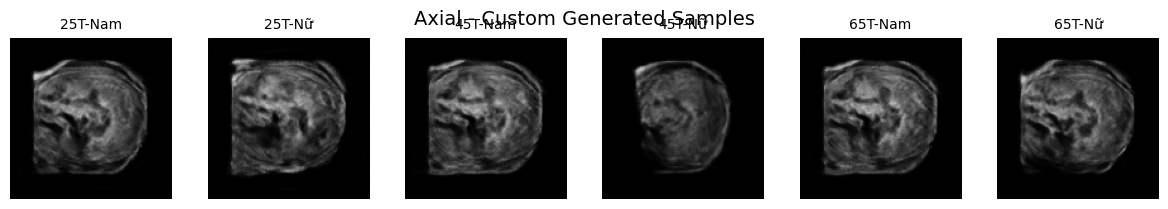

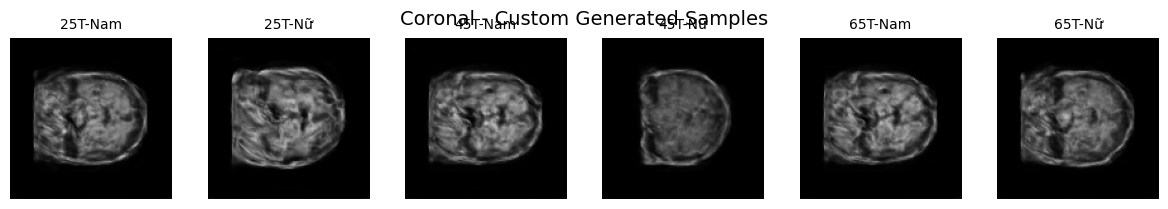

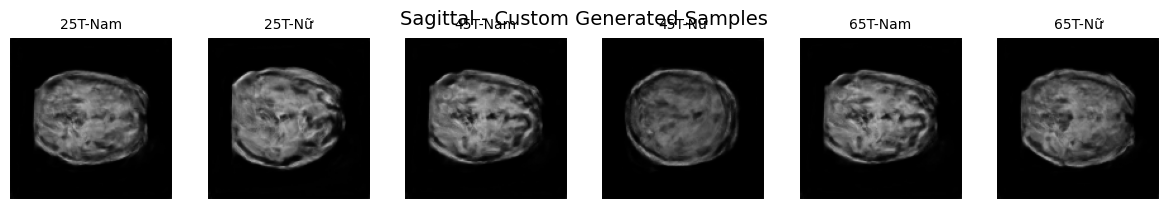

In [24]:
# checkpoint_path = "Weight_path"
checkpoint_path = "/content/lastv1.ckpt"
model = MRIStyleGAN.load_from_checkpoint(checkpoint_path)
custom_ages = [25, 45, 65]  # Tuổi muốn generate
custom_genders = [0, 1]     # 0=nam, 1=nữ
generate_custom_samples(model, custom_ages, custom_genders, num_variations=1)


# Train

In [ ]:
participants_file = "/content/participants.xlsx"
participants_df = pd.read_excel(participants_file)
data_dir = "/content/data/data"


# Lần đầu tiên - tạo và lưu dataloaders
model = train_stylegan(
    data_dir=data_dir,
    participants_df=participants_df,
    batch_size=32,
    num_epochs=100,
    lr=0.0005,
    use_saved_dataloaders=True,
    checkpoint_path="/content/src/StyleGAN/checkpoints/last.ckpt"
)

# Lần sau - chỉ cần load dataloaders đã lưu
# model = train_stylegan(
#     batch_size=16,
#     num_epochs=100,
#     lr=0.0002,
#     use_saved_dataloaders=True,  # Sử dụng dataloaders đã lưu
#     checkpoint_path="/path/to/checkpoint.ckpt"  # Nếu muốn tiếp tục từ checkpoint
# )

Loading saved dataloaders...
Dataloaders loaded from dataloaders.pkl
Loading model from checkpoint: /content/src/StyleGAN/checkpoints/last.ckpt


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
/usr/local/lib/python3.11/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /content/src/StyleGAN/checkpoints exists and is not empty.
INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/src/StyleGAN/checkpoints/last.ckpt
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name          | Type          | Params | Mode 
--------------------------------------------------------
0 | generator     | Generator     | 19.8 M | train
1 | discriminator | Discriminator | 8.9 M  | train
--------------------------------------------------------
28.7 M    Trainable params
0         Non-trainable p

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:
Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined